In [542]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn

Packages required:
- Pyranges
- Pyfaidx

In [3]:
# Read annotation file
annotation = pyranges.read_gtf("RNA Sequencing Data/mm10 gencode reference/gencode.vM10.primary_assembly.annotation.gtf")
annotation

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,transcript_status,transcript_name,transcript_support_level,tag,havana_transcript,exon_number,exon_id,protein_id,ccdsid,ont
0,GL456210.1,ENSEMBL,gene,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL456210.1,ENSEMBL,transcript,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,NaN,NaN,ENSMUSP00000106995.2,NaN,NaN
2,GL456210.1,ENSEMBL,exon,123791,123905,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
3,GL456210.1,ENSEMBL,CDS,123791,123905,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
4,GL456210.1,ENSEMBL,start_codon,123791,123794,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617650,chrY,ENSEMBL,exon,90838868,90839177,.,-,.,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617651,chrY,ENSEMBL,CDS,90838871,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617652,chrY,ENSEMBL,start_codon,90839174,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617653,chrY,ENSEMBL,stop_codon,90838868,90838871,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN


Description of the Narrowpeak format: https://macs3-project.github.io/MACS/docs/narrowPeak.html

In [5]:
# Function for reading narrowpeak files

def load_narrowpeak(filepath):
    """
    Loads a narrowPeak file into a PyRanges object.
    narrowPeak format is fixed: standard BED 6 columns + 4 signal columns.
    """
    columns = [
        "Chromosome", "Start", "End", "Name", "Score", "Strand",
        "SignalValue", "pValue", "qValue", "Peak"
    ]
    # sep='\s+' handles the variable whitespace in the provided snippet
    df = pandas.read_csv(filepath, sep=r'\s+', header=None, names=columns)
    return pyranges.PyRanges(df)

In [6]:
# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
klf4_control_path = chipseq_directory+"KLF4_BFP_merged_peaks.narrowPeak"
klf4_hic2_path = chipseq_directory+"KLF4_Hic2_merged_peaks.narrowPeak"
hic2_path = chipseq_directory+"Ty1_CTer_Hic2_DSG_MKOS48h_peaks.narrowPeak"

klf4_control_peaks = load_narrowpeak(klf4_control_path)
klf4_hic2_peaks = load_narrowpeak(klf4_hic2_path)
hic2_peaks = load_narrowpeak(hic2_path)


array([[<Axes: title={'center': 'qValue'}>]], dtype=object)

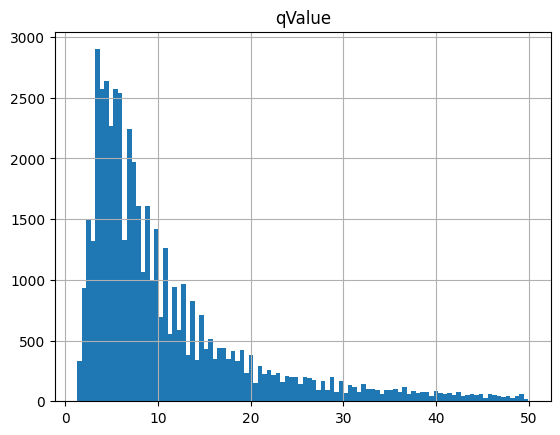

In [406]:
hic2_peaks.as_df()[hic2_peaks.as_df()["qValue"] < 50].hist(column="qValue", bins=100)

In [195]:
hic2_peaks.as_df().sort_values("qValue", ascending=True).head(20)

,Chromosome,Start,End,Name,Score,Strand,SignalValue,pValue,qValue,Peak
40569,chr14,58072038,58072200,Ty1_CTer_Hic2_DSG_MKOS48h_peak_15406,13,.,2.12811,3.43879,1.30620,141
46575,chr17,34110411,34110626,Ty1_CTer_Hic2_DSG_MKOS48h_peak_21412,13,.,2.12811,3.43879,1.30620,184
41871,chr15,36937222,36937387,Ty1_CTer_Hic2_DSG_MKOS48h_peak_16708,13,.,2.12811,3.43879,1.30620,122
50520,chr19,38224082,38224493,Ty1_CTer_Hic2_DSG_MKOS48h_peak_25357,13,.,2.12811,3.43879,1.30620,280
18547,chr6,120856211,120856358,Ty1_CTer_Hic2_DSG_MKOS48h_peak_41306,13,.,2.12811,3.43879,1.30620,146
23674,chr8,68157260,68157560,Ty1_CTer_Hic2_DSG_MKOS48h_peak_46433,13,.,1.98585,3.46273,1.32637,132
45463,chr16,97356578,97356723,Ty1_CTer_Hic2_DSG_MKOS48h_peak_20300,13,.,2.58404,3.53144,1.38379,83
23952,chr8,72160856,72161102,Ty1_CTer_Hic2_DSG_MKOS48h_peak_46711,13,.,2.58404,3.53144,1.38379,1
33419,chr11,84830186,84830417,Ty1_CTer_Hic2_DSG_MKOS48h_peak_8256,13,.,2.58404,3.53144,1.38379,71
23857,chr8,70841111,70841400,Ty1_CTer_Hic2_DSG_MKOS48h_peak_46616,13,.,2.58404,3.53144,1.38379,134


In [ ]:
# Function to map peaks to genes

def find_targets(peak_positions, annotation, upstream=2000, downstream=0, q_value_cutoff=5, return_peaks=False):
    """
    Annotates peaks with genes based on promoter overlap.
    """
    
    # Filter for protein-coding genes
    genes = annotation[
        (annotation.Feature == "gene")
    ]
    
    # Define promoter regions
    promoters = genes.extend({"5": upstream}).spliced_subsequence(0, upstream+downstream)
    
    # Join peaks with promoters
    peak_filter = peak_positions.as_df()["qValue"] > q_value_cutoff
    filtered_peaks = peak_positions[peak_filter]
    targets = promoters.overlap(filtered_peaks).as_df()["gene_name"].unique()
    
    if return_peaks:
        target_peaks = filtered_peaks.overlap(promoters)
        return targets, target_peaks
    else:
        return targets

In [407]:
hic2_targets = find_targets(hic2_peaks, annotation, upstream=2000, downstream=2000, q_value_cutoff=5)
print(f"Found {len(hic2_targets)} targets for Hic2")

Found 11201 targets for Hic2


In [312]:
hic2_targets[:20]

array(['Lypla1', 'Gm37988', 'Tcea1', 'Pcmtd1', 'Cspp1', 'A830018L16Rik',
       'Mir6341', 'Sulf1', 'Gm29570', 'Kcnb2', 'Rdh10', 'Gm28095',
       'Gm38342', 'D030040B21Rik', 'Tmem70', 'Ly96', 'Mir206', 'Gm28653',
       'Paqr8', 'Efhc1'], dtype=object)

In [707]:
# Find Klf4 targets with and without Hic2 overexpression
klf4_hic2_targets = find_targets(klf4_hic2_peaks, annotation, upstream=2000, downstream=2000, q_value_cutoff=5)
print(f"Found {len(klf4_hic2_targets)} targets for Klf4 with Hic2 overexpression")

klf4_control_targets = find_targets(klf4_control_peaks, annotation, upstream=2000, downstream=2000, q_value_cutoff=5)
print(f"Found {len(klf4_control_targets)} targets for Klf4 without Hic2 overexpression")

# Find overlapping binding sites
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
print(f"Found {len(klf4_targets)} overlapping Klf4 targets")

# Shared targets for Hic2 and Klf4
shared_targets = numpy.intersect1d(hic2_targets, klf4_hic2_targets)
print(f"Found {len(shared_targets)} shared targets")

Found 13238 targets for Klf4 with Hic2 overexpression
Found 12931 targets for Klf4 without Hic2 overexpression
Found 12011 overlapping Klf4 targets
Found 9352 shared targets


In [543]:
# Compare to cellrank data

# Read saved objects from Cellrank analysis
working_directory = "RNA Sequencing Data/"
base_name = "cellrank_1.4"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name} cells.h5ad"
)
dead_end_adata = scanpy.read_h5ad(
    working_directory+f"/{base_name} dead end genes.h5ad"
)
mESC_adata = scanpy.read_h5ad(
    working_directory+f"/{base_name} mESC genes.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name} driver genes.csv",
    index_col=0
)

In [408]:
variable_genes = adata.var_names.to_numpy()
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(200).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(200).index.to_numpy()

In [409]:
driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Cd24a,0.666144,0.000000e+00,0.000000e+00,0.654841,0.677150,-0.666161,0.000000e+00,0.000000e+00,-0.677166,-0.654858
Lmo1,0.591418,0.000000e+00,0.000000e+00,0.578225,0.604301,-0.591417,0.000000e+00,0.000000e+00,-0.604301,-0.578224
Crip2,0.579628,0.000000e+00,0.000000e+00,0.566159,0.592789,-0.579637,0.000000e+00,0.000000e+00,-0.592798,-0.566168
Ctsz,0.574877,0.000000e+00,0.000000e+00,0.561298,0.588148,-0.574908,0.000000e+00,0.000000e+00,-0.588177,-0.561329
Lgals7,0.573645,0.000000e+00,0.000000e+00,0.560036,0.586943,-0.573641,0.000000e+00,0.000000e+00,-0.586940,-0.560033
...,...,...,...,...,...,...,...,...,...,...
Myc,0.348143,3.048684e-276,3.044111e-275,0.330400,0.365640,-0.348143,3.053154e-276,3.048575e-275,-0.365640,-0.330400
Map1b,0.347409,5.531969e-275,5.468981e-274,0.329656,0.364916,-0.347409,5.532772e-275,5.469775e-274,-0.364916,-0.329656
Ggh,0.346230,5.711266e-273,5.563609e-272,0.328460,0.363754,-0.346251,5.259579e-273,5.123600e-272,-0.363774,-0.328482


In [410]:
# Find which driver genes are targets for Hic2

hic2_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, hic2_targets)
hic2_dead_end_drivers = numpy.intersect1d(dead_end_drivers, hic2_targets)

In [411]:
hic2_stem_cell_drivers

array(['1700007K13Rik', '2810474O19Rik', 'Agtrap', 'Anxa2', 'Anxa3',
       'Aox3', 'Apoe', 'Arrdc4', 'Atp1b1', 'Blvrb', 'Calcoco2', 'Ccnb2',
       'Ccnf', 'Cenpm', 'Cited2', 'Col18a1', 'Cox6b2', 'Csrp2', 'Ctgf',
       'Cxxc5', 'Dhx16', 'Dnmt3b', 'Enah', 'Epha4', 'Eras', 'Fam208a',
       'Fgfbp1', 'G3bp2', 'Gab1', 'Gadd45b', 'Gdf3', 'Glipr2', 'Gpx4',
       'Hip1', 'Hmgn2', 'Hspb1', 'Ifitm1', 'Jam2', 'Jarid2', 'Klf2',
       'L1td1', 'Lmnb1', 'Lrpap1', 'Ly6e', 'Map1lc3a', 'Marcksl1', 'Mdk',
       'Mme', 'Msh6', 'Mtf2', 'Mycn', 'Mylpf', 'Nid1', 'Nodal', 'Peg10',
       'Phc1', 'Phf11d', 'Phyh', 'Pigp', 'Pla2g1b', 'Platr17', 'Psme1',
       'Psme2', 'Ptma', 'Rbpms2', 'Rdm1', 'Rest', 'Rif1', 'Rnf31',
       'Sfrp1', 'Slc25a20', 'Slc2a1', 'Slc2a3', 'Sparc', 'St8sia1',
       'Tcea3', 'Tcf7l1', 'Tcf7l2', 'Tle4', 'Tln1', 'Tmem40', 'Tmsb10',
       'Trim71', 'Tsc22d1', 'Txnip', 'Ucp2', 'Upp1', 'Wbscr27', 'Zfp42',
       'Zfp462', 'Zic2'], dtype=object)

In [412]:
hic2_dead_end_drivers

array(['9530059O14Rik', 'Abhd16a', 'Ablim1', 'Alox12b', 'Amn', 'Ankrd12',
       'Ankrd13b', 'Anxa5', 'Anxa8', 'Ap1m2', 'Atf3', 'Avil', 'B2m',
       'Birc7', 'Card19', 'Cbr3', 'Ccdc109b', 'Ccl7', 'Ccnd1', 'Ccnd2',
       'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1', 'Cisd3', 'Cltb', 'Crabp2',
       'Crb3', 'Crip2', 'Ctsb', 'Ctsc', 'Ctsz', 'Ddah2', 'Ddit4l',
       'Dgat2', 'Dhrs3', 'Dkkl1', 'Dlgap1', 'Dqx1', 'Dsp', 'Efna3', 'Emb',
       'Emp2', 'Emp3', 'Esd', 'Fabp5', 'Fads3', 'Fam134b', 'Fam195a',
       'Fam83g', 'Fbln2', 'Fbp2', 'Fetub', 'Fgf18', 'Fkbp11', 'Gas5',
       'Gatm', 'Ggh', 'Gpm6b', 'Gprc5a', 'Gsto1', 'Hmgb3', 'Hmha1',
       'Hoxa7', 'Ifi30', 'Ifrd1', 'Isyna1', 'Itgb4', 'Kcnn4', 'Klk10',
       'Klk14', 'Krt13', 'Krt16', 'Krt17', 'Krt8', 'Lad1', 'Lgals7',
       'Lmna', 'Lmo1', 'Ltbp1', 'Ly6g6c', 'Mal', 'Map1b', 'Mgst3', 'Miat',
       'Misp', 'Mt1', 'Mt2', 'Myl7', 'Ndrg1', 'Nkd2', 'Npr3', 'Nradd',
       'Nrip3', 'Obsl1', 'Ovol1', 'P3h4', 'Pcolce', 'Pcolce2', 'Pdgfa',
      

In [413]:
# Overlapping Klf4 targets
klf4_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, klf4_targets)
klf4_dead_end_drivers = numpy.intersect1d(dead_end_drivers, klf4_targets)

In [414]:
klf4_stem_cell_drivers

array(['1700007K13Rik', '2810474O19Rik', 'Aire', 'Anxa2', 'Anxa3', 'Apoe',
       'Arl6ip1', 'Atp1b1', 'Blvrb', 'Bnip3', 'Calcoco2', 'Ccne1', 'Ccnf',
       'Cd59a', 'Cdc5l', 'Cdo1', 'Cenpm', 'Cited2', 'Cox6b2', 'Cox7a1',
       'Csrp2', 'Ctgf', 'Cxxc5', 'Dlc1', 'Dnmt3b', 'Dnmt3l', 'Enah',
       'Epha4', 'Fam208a', 'Fn1', 'G3bp2', 'Gab1', 'Gadd45b', 'Gdf3',
       'Glipr2', 'Gpx4', 'H2afv', 'Hip1', 'Hmgb2', 'Hmgn2', 'Hspb1',
       'Ifitm1', 'Jarid2', 'Kdm3a', 'Klk8', 'L1td1', 'Lmnb1', 'Lrpap1',
       'Map1lc3a', 'Marcksl1', 'Mdk', 'Mkrn1', 'Msh6', 'Mtf2', 'Mycn',
       'Mylpf', 'Nedd4', 'Nid1', 'Nodal', 'Peg10', 'Phc1', 'Phf11d',
       'Phyh', 'Pigp', 'Psme2', 'Ptma', 'Rbpms2', 'Rdm1', 'Rest', 'Rif1',
       'Rnf31', 'Sall1', 'Sfrp1', 'Sh3bgrl3', 'Slc25a20', 'Slc2a1',
       'Slc2a3', 'Snhg11', 'Sparc', 'Suz12', 'Syce2', 'Tcea3', 'Tcf7l1',
       'Tcf7l2', 'Tdgf1', 'Tfcp2l1', 'Tle4', 'Tln1', 'Tmsb10', 'Trim71',
       'Tsc22d1', 'Txnip', 'Ucp2', 'Upp1', 'Zfp42', 'Zic2'], dtype=obj

In [415]:
klf4_dead_end_drivers

array(['5430416N02Rik', '9530059O14Rik', 'Abhd16a', 'Ablim1', 'Ankrd12',
       'Ankrd13b', 'Anxa5', 'Anxa8', 'Aqp3', 'Avil', 'B2m', 'Barx2',
       'Bspry', 'Card19', 'Cbr3', 'Ccdc109b', 'Ccl7', 'Ccnd1', 'Ccnd2',
       'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1', 'Chst13', 'Cisd3', 'Cldn7',
       'Cltb', 'Crabp2', 'Crb3', 'Crip2', 'Ctsb', 'Ctsc', 'Ctsz', 'Ddah2',
       'Ddit4l', 'Dgat2', 'Dhrs3', 'Dkkl1', 'Dlgap1', 'Dsp', 'Efna3',
       'Emb', 'Emp2', 'Emp3', 'Esd', 'Fabp5', 'Fads3', 'Fam134b',
       'Fam195a', 'Fam83g', 'Fbln2', 'Fbp2', 'Fetub', 'Fgf18', 'Fkbp11',
       'Gas5', 'Gatm', 'Gch1', 'Ggh', 'Gprc5a', 'Gsto1', 'Hmgb3', 'Hmha1',
       'Homer2', 'Hoxa7', 'Ifi30', 'Isyna1', 'Itgb4', 'Kcnn4', 'Kiss1r',
       'Klk10', 'Klk14', 'Krt13', 'Krt14', 'Krt16', 'Krt17', 'Krt8',
       'Lgals7', 'Lmna', 'Lmo1', 'Ltbp1', 'Ly6g6c', 'Mal', 'Map1b',
       'Marc2', 'Mgst3', 'Miat', 'Misp', 'Mt1', 'Mt2', 'Myc', 'Myl7',
       'Ndrg1', 'Nkd2', 'Npr3', 'Nradd', 'Nrip3', 'Obsl1', 'Ovol1',
       

In [416]:
# Shared stem cell drivers
shared_stem_cell_drivers = numpy.intersect1d(hic2_stem_cell_drivers, klf4_stem_cell_drivers)
shared_stem_cell_drivers

array(['1700007K13Rik', '2810474O19Rik', 'Anxa2', 'Anxa3', 'Apoe',
       'Atp1b1', 'Blvrb', 'Calcoco2', 'Ccnf', 'Cenpm', 'Cited2', 'Cox6b2',
       'Csrp2', 'Ctgf', 'Cxxc5', 'Dnmt3b', 'Enah', 'Epha4', 'Fam208a',
       'G3bp2', 'Gab1', 'Gadd45b', 'Gdf3', 'Glipr2', 'Gpx4', 'Hip1',
       'Hmgn2', 'Hspb1', 'Ifitm1', 'Jarid2', 'L1td1', 'Lmnb1', 'Lrpap1',
       'Map1lc3a', 'Marcksl1', 'Mdk', 'Msh6', 'Mtf2', 'Mycn', 'Mylpf',
       'Nid1', 'Nodal', 'Peg10', 'Phc1', 'Phf11d', 'Phyh', 'Pigp',
       'Psme2', 'Ptma', 'Rbpms2', 'Rdm1', 'Rest', 'Rif1', 'Rnf31',
       'Sfrp1', 'Slc25a20', 'Slc2a1', 'Slc2a3', 'Sparc', 'Tcea3',
       'Tcf7l1', 'Tcf7l2', 'Tle4', 'Tln1', 'Tmsb10', 'Trim71', 'Tsc22d1',
       'Txnip', 'Ucp2', 'Upp1', 'Zfp42', 'Zic2'], dtype=object)

In [417]:
# Shared dead end drivers
shared_dead_end_drivers = numpy.intersect1d(hic2_dead_end_drivers, klf4_dead_end_drivers)
shared_dead_end_drivers

array(['9530059O14Rik', 'Abhd16a', 'Ablim1', 'Ankrd12', 'Ankrd13b',
       'Anxa5', 'Anxa8', 'Avil', 'B2m', 'Card19', 'Cbr3', 'Ccdc109b',
       'Ccl7', 'Ccnd1', 'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1',
       'Cisd3', 'Cltb', 'Crabp2', 'Crb3', 'Crip2', 'Ctsb', 'Ctsc', 'Ctsz',
       'Ddah2', 'Ddit4l', 'Dgat2', 'Dhrs3', 'Dkkl1', 'Dlgap1', 'Dsp',
       'Efna3', 'Emb', 'Emp2', 'Emp3', 'Esd', 'Fabp5', 'Fads3', 'Fam134b',
       'Fam195a', 'Fam83g', 'Fbln2', 'Fbp2', 'Fetub', 'Fgf18', 'Fkbp11',
       'Gas5', 'Gatm', 'Ggh', 'Gprc5a', 'Gsto1', 'Hmgb3', 'Hmha1',
       'Hoxa7', 'Ifi30', 'Isyna1', 'Itgb4', 'Kcnn4', 'Klk10', 'Klk14',
       'Krt13', 'Krt16', 'Krt17', 'Krt8', 'Lgals7', 'Lmna', 'Lmo1',
       'Ltbp1', 'Ly6g6c', 'Mal', 'Map1b', 'Mgst3', 'Miat', 'Misp', 'Mt1',
       'Mt2', 'Myl7', 'Ndrg1', 'Nkd2', 'Npr3', 'Nradd', 'Nrip3', 'Obsl1',
       'Ovol1', 'P3h4', 'Pcolce', 'Pcolce2', 'Pdgfa', 'Perp', 'Pga5',
       'Phlda3', 'Plec', 'Plek2', 'Pmepa1', 'Ppa1', 'Prkaa2', 'Prkcdbp',
  

In [418]:
"Cdh1" in hic2_targets

False

The most interesting shared targets among the dead end drivers are:
- Genes involved in epithelial cell differentiation: KRT17;KRT16;KRT13;OVOL1;CTSB
- Genes involved in epidermal development: CRABP2;FABP5;KLK14;OVOL1

Especially Ovol1 and the keratin genes are relevant. Ovol1 promotes mesenchymal-to-epithelial transition

The most interesting stem cell drivers are:
- Genes regulating epithelial to mesenchymal transition: EPHA4;TCF7L2;SFRP1;MDK;GLIPR2

Mdk is especially interesting as a driver of EMT with interesting expression trends.

# GO analysis

## GO biological process

In [419]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Supramolecular Fiber Organization (GO:0097435),9/339,0.000557,0.259396,0,0,4.161861,31.188181,TPPP3;KRT17;KRT16;AVIL;KRT13;TRPV3;P3H4;EMP2;B2M
1,GO_Biological_Process_2025,Bleb Assembly (GO:0032060),2/6,0.000686,0.259396,0,0,73.551852,535.773236,EMP2;EMP3
2,GO_Biological_Process_2025,Collagen Biosynthetic Process (GO:0032964),2/9,0.001625,0.309994,0,0,42.023280,269.886732,P3H4;PCOLCE
3,GO_Biological_Process_2025,Epithelial Cell Differentiation (GO:0030855),5/132,0.002163,0.309994,0,0,5.886423,36.119586,KRT17;KRT16;KRT13;OVOL1;CTSB
4,GO_Biological_Process_2025,Regulation of Sprouting Angiogenesis (GO:1903670),3/38,0.002226,0.309994,0,0,12.683156,77.463593,S100A1;FGF18;TGM2
5,GO_Biological_Process_2025,Fatty Acid Homeostasis (GO:0055089),2/11,0.002460,0.309994,0,0,32.681481,196.333458,DGAT2;PRKAA2
6,GO_Biological_Process_2025,Epidermis Development (GO:0008544),4/86,0.002899,0.313075,0,0,7.255089,42.394705,CRABP2;FABP5;KLK14;OVOL1
7,GO_Biological_Process_2025,Monoacylglycerol Metabolic Process (GO:0046462),2/13,0.003458,0.326776,0,0,26.736700,151.519063,DGAT2;ABHD16A
15,GO_Biological_Process_2025,Nuclear Envelope Organization (GO:0006998),2/19,0.007380,0.348701,0,0,17.294989,84.900968,TMEM43;LMNA
13,GO_Biological_Process_2025,Positive Regulation of Purine Nucleotide Catab...,2/19,0.007380,0.348701,0,0,17.294989,84.900968,UCHL1;PRKAA2


Epithelial cell differentiation and epidermis development is included.

In [420]:
# Enriched terms among the stem celldrivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Positive Regulation of Cell Differentiation (G...,9/297,0.000001,0.001024,0,0,9.742063,133.086588,TCF7L2;IFITM1;SFRP1;TCF7L1;REST;MDK;GLIPR2;GDF...
1,GO_Biological_Process_2025,Regulation of Epithelial to Mesenchymal Transi...,5/91,0.000019,0.005919,0,0,17.217980,186.996971,EPHA4;TCF7L2;SFRP1;MDK;GLIPR2
2,GO_Biological_Process_2025,Positive Regulation of Cell Adhesion (GO:0045785),5/92,0.000020,0.005919,0,0,17.019214,183.934641,EPHA4;CITED2;MDK;NID1;NODAL
3,GO_Biological_Process_2025,Negative Regulation of Gene Expression (GO:001...,8/364,0.000048,0.009255,0,0,6.872191,68.288050,TRIM71;EPHA4;SFRP1;REST;MYCN;CITED2;MTF2;APOE
4,GO_Biological_Process_2025,Negative Regulation of Cell Migration (GO:0030...,6/184,0.000053,0.009255,0,0,10.086823,99.351297,EPHA4;IFITM1;SFRP1;CITED2;APOE;NODAL
5,GO_Biological_Process_2025,Negative Regulation of Canonical Wnt Signaling...,5/117,0.000064,0.009405,0,0,13.203625,127.431293,TLE4;TCF7L2;SFRP1;MDK;APOE
6,GO_Biological_Process_2025,L-ascorbic Acid Metabolic Process (GO:0019852),2/5,0.000127,0.013912,0,0,189.761905,1702.551352,SLC2A1;SLC2A3
7,GO_Biological_Process_2025,Maintenance of DNA Repeat Elements (GO:0043570),2/5,0.000127,0.013912,0,0,189.761905,1702.551352,MSH6;TCF7L2
8,GO_Biological_Process_2025,Negative Regulation of Wnt Signaling Pathway (...,5/146,0.000183,0.016656,0,0,10.472637,90.141717,TLE4;TCF7L2;SFRP1;MDK;APOE
9,GO_Biological_Process_2025,Positive Regulation of Amyloid-Beta Clearance ...,2/6,0.000190,0.016656,0,0,142.314286,1219.477712,LRPAP1;APOE


Regulation of epithelial-to-mesenchymal transition is a top term. Mdk is especially interesting as it promotes epithelial to mesenchymal transition.

In [440]:
# Prerank analysis on filtered dataframe, dead end drivers

rank_data = driver_df[["Day 12 Control_corr"]].sort_values('Day 12 Control_corr', ascending=False).dropna()
# Filter out genes that are not targets
rank_data = rank_data.query("gene_names in @shared_targets")

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="GO_Biological_Process_2025",
    threads=16,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values('NES', ascending=False).head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
5,prerank,Epithelial Cell Differentiation (GO:0030855),0.733746,1.764349,0.007067,0.526364,0.478,5/11,14.42%,Ovol1;Ctsb;Krt17;Krt13;Krt16
7,prerank,Protein Catabolic Process (GO:0030163),0.752835,1.705927,0.008977,0.595924,0.743,4/10,9.53%,Ctsz;Uchl1;Ctsb;Ctsc
13,prerank,Proteolysis Involved in Protein Catabolic Proc...,0.831586,1.663199,0.005495,0.679134,0.884,3/6,9.53%,Ctsz;Ctsb;Ctsc
27,prerank,Protein Metabolic Process (GO:0019538),0.485703,1.566431,0.019544,1.0,0.989,11/39,13.96%,Ctsz;Uchl1;B2m;Ctsb;Pcolce;Cisd3;Ctsc;Pga5;Klk...
37,prerank,Cellular Response to Chemical Stress (GO:0062197),0.790754,1.515082,0.032787,1.0,0.998,1/5,3.06%,Prkaa2
42,prerank,Positive Regulation of Carbohydrate Metabolic ...,0.727314,1.483575,0.058716,1.0,0.999,2/6,3.06%,Uchl1;Prkaa2
46,prerank,Positive Regulation of ATP Metabolic Process (...,0.7727,1.475131,0.039548,1.0,0.999,2/5,3.06%,Uchl1;Prkaa2
47,prerank,Peptide Hormone Processing (GO:0016486),0.77891,1.47427,0.051565,1.0,0.999,1/5,0.45%,Ctsz
54,prerank,Regulation of Glycolytic Process (GO:0006110),0.754411,1.459598,0.058052,1.0,1.0,2/5,3.06%,Uchl1;Prkaa2
55,prerank,Protein Localization to Organelle (GO:0033365),0.726421,1.455196,0.075901,1.0,1.0,3/6,7.49%,Prkaa2;Lmna;Obsl1


In [444]:
# Prerank analysis on filtered dataframe, stem cell drivers

rank_data = driver_df[["mESC_corr"]].sort_values("mESC_corr", ascending=False).dropna()
# Filter out genes that are not targets
rank_data = rank_data.query("gene_names in @shared_targets")

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="GO_Biological_Process_2025",
    threads=16,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values('NES', ascending=False).head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Chromatin Organization (GO:0006325),0.819883,2.063664,0.0,0.025274,0.017,7/11,11.12%,Hmgn2;Jarid2;Phc1;Tcf7l1;Rest;Kdm5b;Cecr2
1,prerank,Chromatin Remodeling (GO:0006338),0.831708,2.02792,0.0,0.016354,0.021,6/10,11.12%,Jarid2;Phc1;Mtf2;Rest;Kdm5b;Cecr2
2,prerank,Nervous System Development (GO:0007399),0.552651,1.960614,0.0,0.033203,0.058,18/43,21.68%,Mdk;Jarid2;Trim71;Zic2;Slc2a1;Marcksl1;Marcks;...
3,prerank,Regulation of Insulin Secretion (GO:0050796),0.895669,1.874228,0.0,0.096637,0.194,3/6,8.17%,Rest;Sfrp1;Tcf7l2
6,prerank,Protein-Containing Complex Assembly (GO:0065003),0.604726,1.770031,0.012853,0.302994,0.535,10/20,26.11%,Gpx4;Slc2a1;Hip1;Tcf7l2;Nrxn1;Lamc1;Mapt;Fermt...
7,prerank,Positive Regulation of RNA Biosynthetic Proces...,0.499344,1.742913,0.002688,0.353592,0.636,9/38,8.17%,Tcf7l1;Rest;Klf2;Apoe;Cited2;Mycn;Zic2;Sfrp1;T...
9,prerank,Central Nervous System Development (GO:0007417),0.535446,1.684552,0.00241,0.611256,0.865,10/25,17.48%,Jarid2;Zic2;Slc2a1;Marcksl1;Ptch1;Marcks;Msi2;...
10,prerank,Positive Regulation of Cell Differentiation (G...,0.464476,1.678771,0.002674,0.569601,0.882,18/48,25.09%,Mdk;Gdf3;Tcf7l1;Ifitm1;Rest;Glipr2;Nid1;Sfrp1;...
11,prerank,Negative Regulation of Protein Secretion (GO:0...,0.813247,1.666585,0.010661,0.57404,0.916,4/6,12.49%,Rest;Apoe;Sfrp1;Rab11fip1
12,prerank,Positive Regulation of DNA-binding Transcripti...,0.639384,1.654946,0.016317,0.584728,0.932,5/12,8.06%,Tcf7l1;Nodal;Zic2;Anxa3;Rnf31


## MSigDB Hallmark

In [422]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='MSigDB_Hallmark_2020',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,p53 Pathway,11/200,1.341382e-07,0.000005,0,0,9.087680,143.807033,CDKN1A;CCND2;KRT17;ITGB4;PERP;PDGFA;IFI30;NDRG...
1,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,9/199,9.539139e-06,0.000136,0,0,7.280304,84.161099,CCND2;S100A1;GSTO1;CTSZ;NDRG1;DHRS3;CD44;TGM2;...
2,MSigDB_Hallmark_2020,Estrogen Response Early,9/200,9.931283e-06,0.000136,0,0,7.241819,83.424462,ABLIM1;CCND1;KRT8;KRT13;TOB1;KLK10;DHRS3;CD44;...
3,MSigDB_Hallmark_2020,Androgen Response,6/100,6.508419e-05,0.000494,0,0,9.632451,92.855178,CCND1;KRT8;PMEPA1;SAT1;B2M;NDRG1
4,MSigDB_Hallmark_2020,Estrogen Response Late,8/200,7.222413e-05,0.000494,0,0,6.353682,60.587038,CCND1;FABP5;PERP;KRT13;EMP2;TOB1;KLK10;CD44
5,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,8/200,7.222413e-05,0.000494,0,0,6.353682,60.587038,PCOLCE2;PMEPA1;PCOLCE;EMP3;FBLN2;SAT1;CD44;TGM2
6,MSigDB_Hallmark_2020,Apoptosis,6/161,8.555291e-04,0.005011,0,0,5.823590,41.136621,CDKN1A;CCND2;CCND1;LMNA;SAT1;CD44
10,MSigDB_Hallmark_2020,mTORC1 Signaling,5/200,1.228543e-02,0.041975,0,0,3.820513,16.807739,CDKN1A;PPA1;IFI30;TUBA4A;CTSC
9,MSigDB_Hallmark_2020,Interferon Gamma Response,5/200,1.228543e-02,0.041975,0,0,3.820513,16.807739,CDKN1A;CCL7;IFI30;B2M;PSMB10
11,MSigDB_Hallmark_2020,Xenobiotic Metabolism,5/200,1.228543e-02,0.041975,0,0,3.820513,16.807739,DDAH2;GSTO1;FETUB;SPINT2;PSMB10


In [ ]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='MSigDB_Hallmark_2020',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,Interferon Alpha Response,4/97,0.000415,0.009021,0,0,12.545857,97.682546,RNF31;IFITM1;PSME2;TXNIP
1,MSigDB_Hallmark_2020,Hypoxia,5/200,0.000773,0.009021,0,0,7.551856,54.108220,CSRP2;ANXA2;CITED2;SLC2A1;SLC2A3
2,MSigDB_Hallmark_2020,Adipogenesis,5/200,0.000773,0.009021,0,0,7.551856,54.108220,PHYH;GPX4;UCP2;G3BP2;APOE
3,MSigDB_Hallmark_2020,Apoptosis,4/161,0.002721,0.023807,0,0,7.407643,43.755806,GPX4;GADD45B;HSPB1;TXNIP
4,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,4/199,0.005776,0.025715,0,0,5.952640,30.680479,GPX4;GADD45B;GLIPR2;SLC2A3
5,MSigDB_Hallmark_2020,G2-M Checkpoint,4/200,0.005878,0.025715,0,0,5.921969,30.418637,MTF2;CCNF;HMGN2;LMNB1
6,MSigDB_Hallmark_2020,Interferon Gamma Response,4/200,0.005878,0.025715,0,0,5.921969,30.418637,RNF31;PSME2;TXNIP;UPP1
7,MSigDB_Hallmark_2020,Oxidative Phosphorylation,4/200,0.005878,0.025715,0,0,5.921969,30.418637,PHYH;GPX4;SLC25A20;ATP1B1
14,MSigDB_Hallmark_2020,heme Metabolism,3/200,0.035518,0.082874,0,0,4.354668,14.534704,UCP2;SLC2A1;BLVRB
13,MSigDB_Hallmark_2020,p53 Pathway,3/200,0.035518,0.082874,0,0,4.354668,14.534704,TSC22D1;TXNIP;UPP1


## Targets of transcription factors

In [445]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='ChEA_2022',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2022,SUZ12 20075857 ChIP-Seq MESCs Mouse,54/3611,3.381466e-09,0.000001,0,0,2.982492,58.173370,ANKRD13B;CDKN1A;RTKN;ITGB4;TNFRSF13C;FADS3;RAS...
1,ChEA_2022,RING1B 27294783 Chip-Seq ESCs Mouse,34/1651,4.049021e-09,0.000001,0,0,3.724769,71.980382,TSHZ1;NPR3;PDGFA;CRIP2;IFI30;NDRG1;PSMB10;NKD2...
2,ChEA_2022,TP53 23651856 ChIP-Seq MEFs Mouse,39/2541,6.761689e-07,0.000133,0,0,2.761379,39.230418,RTN4R;ISYNA1;CDKN1A;RTKN;ITGB4;AVIL;TSHZ1;PDGF...
3,ChEA_2022,KLF4 18358816 ChIP-ChIP MESCs Mouse,25/1238,9.787532e-07,0.000133,0,0,3.431943,47.487743,CDKN1A;MGST3;NPR3;PDGFA;IFI30;NDRG1;RASSF1;TUB...
4,ChEA_2022,SMAD2 18955504 ChIP-ChIP HaCaT Human,28/1513,1.117285e-06,0.000133,0,0,3.179094,43.568234,CDKN1A;CRABP2;MGST3;CTSZ;NDRG1;TOB1;SAT1;ABLIM...
5,ChEA_2022,SMAD3 18955504 ChIP-ChIP HaCaT Human,28/1513,1.117285e-06,0.000133,0,0,3.179094,43.568234,CDKN1A;CRABP2;MGST3;CTSZ;NDRG1;TOB1;SAT1;ABLIM...
6,ChEA_2022,SOX2 20726797 ChIP-Seq SW620 Human,32/1931,1.824011e-06,0.000186,0,0,2.882961,38.096808,RTN4R;FKBP11;CRABP2;TSHZ1;CTSZ;PDGFA;CRIP2;SPI...
7,ChEA_2022,RACK7 27058665 Chip-Seq MCF-7 Human,29/1679,2.771378e-06,0.000248,0,0,2.963956,37.927276,ISYNA1;CRABP2;NPR3;PDGFA;CRIP2;CISD3;PSMB10;FA...
8,ChEA_2022,ESR1 26153859 ChIP-Seq MCF-7 Human BreastCancer,47/3597,3.418441e-06,0.000272,0,0,2.399721,30.203676,FKBP11;ISYNA1;RTKN;ITGB4;ANKRD12;NPR3;CTSZ;CLT...
9,ChEA_2022,EP300 20729851 ChIP-Seq FORBRAIN MIDBRAIN LIMB...,24/1313,9.185166e-06,0.000657,0,0,3.060450,35.494859,LMO1;RTN4R;MGST3;KRT8;PDGFA;CRIP2;FBLN2;DHRS3;...


In [446]:
# Stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='ChEA_2022',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2022,NACC1 18358816 ChIP-ChIP MESCs Mouse,25/554,3.064735e-21,2.151444e-18,0,0,19.505892,921.347673,LRPAP1;IFITM1;RIF1;CITED2;SLC2A3;RDM1;ZIC2;SLC...
1,ChEA_2022,SOX2 18692474 ChIP-Seq MESCs Mouse,41/2302,1.368620e-20,4.803855e-18,0,0,10.334380,472.672813,TRIM71;LRPAP1;IFITM1;HIP1;RIF1;HSPB1;SLC2A3;CX...
2,ChEA_2022,SOX2 18692474 ChIP-Seq MEFs Mouse,35/1566,3.291095e-20,7.701162e-18,0,0,11.366798,509.920028,LRPAP1;IFITM1;RIF1;HSPB1;SLC2A3;CXXC5;ZIC2;MDK...
3,ChEA_2022,OCT4 18692474 ChIP-Seq MEFs Mouse,35/1655,1.955679e-19,3.432216e-17,0,0,10.690357,460.523257,LRPAP1;SPARC;RIF1;CITED2;SLC2A1;HSPB1;SLC2A3;C...
4,ChEA_2022,TCF3 18347094 ChIP-ChIP MESCs Mouse,33/1613,9.373793e-18,1.316081e-15,0,0,9.826095,385.267581,TRIM71;LRPAP1;IFITM1;SPARC;RIF1;SLC2A1;HSPB1;S...
5,ChEA_2022,NANOG 18347094 ChIP-ChIP MESCs Mouse,31/1399,1.507405e-17,1.763664e-15,0,0,10.258166,397.335247,TRIM71;LRPAP1;IFITM1;HIP1;SPARC;RIF1;CITED2;HS...
6,ChEA_2022,POU5F1 18347094 ChIP-ChIP MESCs Mouse,32/1555,3.122947e-17,3.131870e-15,0,0,9.667761,367.424895,TRIM71;LRPAP1;IFITM1;SPARC;RIF1;CITED2;PIGP;CX...
7,ChEA_2022,POU5F1 18692474 ChIP-Seq MESCs Mouse,41/3012,2.661369e-16,2.335352e-14,0,0,7.548637,270.713144,TRIM71;LRPAP1;IFITM1;SPARC;RIF1;CITED2;SLC2A1;...
9,ChEA_2022,NANOG 18692474 ChIP-Seq MESCs Mouse,35/2172,1.039925e-15,7.300273e-14,0,0,7.875210,271.691824,TRIM71;LRPAP1;IFITM1;RIF1;SLC2A1;SLC2A3;ZIC2;P...
8,ChEA_2022,SOX2 18358816 ChIP-ChIP MESCs Mouse,21/591,1.015156e-15,7.300273e-14,0,0,13.984107,482.783606,EPHA4;LRPAP1;IFITM1;PHC1;SPARC;RIF1;CITED2;GDF...


## Upregulated or downregulated by a specific transcription factor

In [495]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='TF_Perturbations_Followed_by_Expression',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,TF_Perturbations_Followed_by_Expression,ARID3A KD MOUSE GSE56853 CREEDSID GENE 1337 UP,19/329,1.157843e-12,2.137378e-09,0,0,10.156014,279.132590,DSP;CGREF1;CDKN1A;RTKN;CRABP2;ANXA5;KRT8;DDIT4...
1,TF_Perturbations_Followed_by_Expression,SRF MUT MOUSE GSE1948 CREEDSID GENE 1400 UP,17/264,3.430517e-12,3.166367e-09,0,0,11.250742,297.000583,DSP;CDKN1A;CRABP2;GSTO1;ANXA5;KRT8;PDGFA;PCOLC...
2,TF_Perturbations_Followed_by_Expression,RARA KD HUMAN GSE26298 CREEDSID GENE 69 UP,17/290,1.531343e-11,9.172618e-09,0,0,10.165751,253.150486,DSP;CDKN1A;ZFAS1;KRT8;SPINT2;IFI30;TOB1;SAT1;P...
3,TF_Perturbations_Followed_by_Expression,OVOL2 OE MDA HUMAN GSE51975 RNASEQ UP,14/179,2.304498e-11,9.172618e-09,0,0,13.588174,332.822946,DSP;CDKN1A;ITGB4;KRT8;SPINT2;TUBA4A;PERP;TMBIM...
4,TF_Perturbations_Followed_by_Expression,TFAP2C KD MOUSE GSE10175 CREEDSID GENE 1498 UP,14/180,2.484458e-11,9.172618e-09,0,0,13.505632,329.785683,DGAT2;CRABP2;GSTO1;SMAGP;KRT8;SPINT2;IFI30;FET...
5,TF_Perturbations_Followed_by_Expression,IRF6 KO MOUSE GSE5800 CREEDSID GENE 153 UP,15/253,2.207564e-10,6.791940e-08,0,0,10.138277,225.414048,DSP;CRABP2;GSTO1;NDRG1;SAT1;TUBA4A;KRT17;FABP5...
6,TF_Perturbations_Followed_by_Expression,FOXD3 KO MOUSE GSE58960 CREEDSID GENE 1417 UP,15/270,5.454405e-10,1.251084e-07,0,0,9.454195,201.652561,CDKN1A;GSTO1;ANXA5;CTSZ;FBLN2;SAT1;CCND2;CCND1...
7,TF_Perturbations_Followed_by_Expression,KDM2B KD MOUSE GSE41298 CREEDSID GENE 1376 UP,13/189,6.090039e-10,1.251084e-07,0,0,11.727044,248.838443,RTKN;GSTO1;ANXA5;NPR3;KRT8;DDIT4L;CRIP2;GATM;C...
8,TF_Perturbations_Followed_by_Expression,OVOL2 OE MOUSE GSE55074 CREEDSID GENE 2603 DOWN,14/229,6.099543e-10,1.251084e-07,0,0,10.401664,220.698728,DSP;GSTO1;KRT13;PDGFA;EMP2;KLK10;TUBA4A;CCND2;...
9,TF_Perturbations_Followed_by_Expression,KMT2A KO MOUSE GSE24964 CREEDSID GENE 3009 UP,14/234,8.089137e-10,1.493255e-07,0,0,10.162676,212.758955,ANXA5;CTSZ;PDGFA;EMP2;EMP3;TUBA4A;FADS3;GPRC5A...


In [496]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='TF_Perturbations_Followed_by_Expression',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,TF_Perturbations_Followed_by_Expression,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 1660 DOWN,19/301,7.669632e-19,8.681847e-16,0,0,24.974843,1041.746848,IFITM1;PHC1;GPX4;RIF1;GAB1;HSPB1;SLC2A3;ENAH;M...
1,TF_Perturbations_Followed_by_Expression,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 2289 DOWN,19/305,9.832217e-19,8.681847e-16,0,0,24.620530,1020.852190,IFITM1;PHC1;SPARC;GPX4;RIF1;GAB1;HSPB1;SLC2A3;...
2,TF_Perturbations_Followed_by_Expression,MSGN1 OE MOUSE GSE29848 CREEDSID GENE 1631 DOWN,18/299,1.669464e-17,9.827580e-15,0,0,23.306050,900.346353,TCF7L1;PHC1;GPX4;RIF1;SLC2A1;SLC2A3;MSH6;ZIC2;...
3,TF_Perturbations_Followed_by_Expression,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 2585 DOWN,18/309,2.992100e-17,1.321012e-14,0,0,22.493700,855.839644,TCF7L1;GPX4;GAB1;SLC2A1;HSPB1;SLC2A3;LMNB1;CSR...
4,TF_Perturbations_Followed_by_Expression,FOXD3 OE MOUSE GSE58960 CREEDSID GENE 1415 DOWN,17/274,8.854522e-17,3.127417e-14,0,0,23.658083,874.474147,IFITM1;PHC1;CALCOCO2;HSPB1;SLC2A3;ENAH;MSH6;MY...
5,TF_Perturbations_Followed_by_Expression,MSGN1 OE MOUSE GSE29848 CREEDSID GENE 1629 DOWN,18/349,2.559061e-16,7.532170e-14,0,0,19.735146,708.525707,GPX4;HSPB1;LMNB1;CTGF;ENAH;MSH6;CSRP2;ZIC2;ZFP...
6,TF_Perturbations_Followed_by_Expression,SOX2 KD MOUSE GSE39771 CREEDSID GENE 1757 DOWN,16/282,3.232046e-15,8.153991e-13,0,0,21.119227,704.656956,IFITM1;PHC1;RIF1;LMNB1;ENAH;MSH6;MYCN;CSRP2;MT...
7,TF_Perturbations_Followed_by_Expression,SOX2 KD MOUSE GSE39771 CREEDSID GENE 1757 UP,15/254,1.444474e-14,3.188676e-12,0,0,21.679146,690.880684,LRPAP1;SPARC;ANXA2;GPX4;TSC22D1;ANXA3;CITED2;C...
8,TF_Perturbations_Followed_by_Expression,KLF5 KO MOUSE GSE9244 CREEDSID GENE 580 DOWN,16/315,1.820915e-14,3.573040e-12,0,0,18.756808,593.406374,IFITM1;PHC1;TSC22D1;GAB1;SLC2A1;HSPB1;SLC2A3;L...
9,TF_Perturbations_Followed_by_Expression,MTF2 KD MOUSE GSE16364 CREEDSID GENE 1355 UP,14/213,2.724469e-14,4.811412e-12,0,0,23.930515,747.443730,IFITM1;GPX4;RIF1;HSPB1;ENAH;MSH6;RDM1;CSRP2;ZF...


## Cell types

In [447]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='PanglaoDB_Augmented_2021',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,PanglaoDB_Augmented_2021,Keratinocytes,10/127,1.729429e-08,9.947702e-07,0,0,13.288916,237.511325,KRT17;ITGB4;KRT16;PERP;KRT13;ANXA8;S100A14;OVO...
1,PanglaoDB_Augmented_2021,Trophoblast Cells,10/130,2.165186e-08,9.947702e-07,0,0,12.954724,228.627235,GPRC5A;KRT17;SMAGP;KRT16;PERP;PLEK2;ANXA8;S100...
2,PanglaoDB_Augmented_2021,Trophoblast Stem Cells,9/99,2.617816e-08,9.947702e-07,0,0,15.447656,269.690439,DSP;CCND1;CRABP2;KRT16;PERP;KRT8;EMP2;S100A14;...
3,PanglaoDB_Augmented_2021,Trichocytes,9/103,3.708818e-08,1.057013e-06,0,0,14.787317,253.010518,DSP;GPRC5A;KRT17;ITGB4;KRT16;PERP;KRT8;S100A14...
4,PanglaoDB_Augmented_2021,Mammary Epithelial Cells,9/134,3.605094e-07,8.219614e-06,0,0,11.102625,164.715745,DSP;KRT17;ITGB4;KRT16;PERP;KRT8;S100A14;OVOL1;...
5,PanglaoDB_Augmented_2021,Epithelial Cells,10/218,2.646586e-06,5.028513e-05,0,0,7.440566,95.553539,DGAT2;KRT16;ITGB4;KRT8;KRT13;S100A14;OVOL1;MIS...
6,PanglaoDB_Augmented_2021,Luminal Epithelial Cells,8/140,5.516182e-06,8.285789e-05,0,0,9.269908,112.238424,DSP;ITGB4;PERP;KRT8;S100A14;OVOL1;MISP;CRB3
7,PanglaoDB_Augmented_2021,Basal Cells,8/141,5.814589e-06,8.285789e-05,0,0,9.199744,110.904201,KRT17;KRT16;ITGB4;PERP;LMNA;PLEK2;ANXA8;S100A14
8,PanglaoDB_Augmented_2021,Microfold Cells,7/126,2.600914e-05,3.294491e-04,0,0,8.933937,94.316127,FABP5;CTSZ;ANXA5;TMBIM1;IFI30;SAT1;CTSB
9,PanglaoDB_Augmented_2021,Salivary Mucous Cells,6/105,8.544692e-05,9.740949e-04,0,0,9.143650,85.654197,KRT17;KRT16;ANXA8;EMP2;S100A14;LGALS7


In [448]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='PanglaoDB_Augmented_2021',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,PanglaoDB_Augmented_2021,Epiblast Cells,6/109,0.000003,0.000192,0,0,17.497793,224.616633,TRIM71;MYCN;PHC1;DNMT3B;L1TD1;GDF3
1,PanglaoDB_Augmented_2021,Osteocytes,5/98,0.000027,0.000940,0,0,15.916386,167.144603,ENAH;SFRP1;TCF7L1;CSRP2;MDK
2,PanglaoDB_Augmented_2021,Embryonic Stem Cells,6/176,0.000041,0.000940,0,0,10.565775,106.688081,ENAH;SFRP1;ZFP42;DNMT3B;L1TD1;GDF3
3,PanglaoDB_Augmented_2021,Pluripotent Stem Cells,5/112,0.000052,0.000940,0,0,13.824104,136.300297,MSH6;TRIM71;CCNF;DNMT3B;GDF3
4,PanglaoDB_Augmented_2021,Chondrocytes,4/146,0.001908,0.027480,0,0,8.196355,51.321824,SFRP1;SPARC;GADD45B;NID1
5,PanglaoDB_Augmented_2021,His Bundle Cells,3/98,0.005328,0.063935,0,0,9.076888,47.515684,ENAH;SFRP1;CSRP2
6,PanglaoDB_Augmented_2021,Hematopoietic Stem Cells,3/178,0.026417,0.271721,0,0,4.907578,17.832830,MYCN;DNMT3B;TXNIP
7,PanglaoDB_Augmented_2021,Fibroblasts,3/232,0.051267,0.342317,0,0,3.740080,11.110681,SPARC;MDK;UCP2
8,PanglaoDB_Augmented_2021,Mast Cells,3/235,0.052892,0.342317,0,0,3.691154,10.850165,ENAH;TCF7L1;SPARC
9,PanglaoDB_Augmented_2021,Motor Neurons,2/111,0.060702,0.342317,0,0,5.195020,14.555288,ENAH;ZIC2


# Check which driver targets are transcription factors

Source for list of transcription factors: https://guolab.wchscu.cn/AnimalTFDB#!/download

In [456]:
tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [ ]:
# Dead end drivers which are TFs

shared_dead_end_tfs = numpy.intersect1d(shared_dead_end_drivers, tf_array)
shared_dead_end_tfs

array(['Hmgb3', 'Hoxa7', 'Ovol1', 'Tlx2', 'Tshz1'], dtype=object)

Ovol1 is the most interesting target. Cdh1 also looks like it could be a Hic2 target, but the narrowpeak file has removed the peak, likely due to a low q-value. The narrowpeak also does not list the peak for Klf4 even though it is a known target of Klf4.

In [ ]:
# Stem cell drivers which are TFs

shared_stem_cell_tfs = numpy.intersect1d(shared_stem_cell_drivers, tf_array)
shared_stem_cell_tfs

array(['Jarid2', 'Mycn', 'Rest', 'Tcf7l1', 'Tcf7l2', 'Tsc22d1', 'Zfp42',
       'Zic2'], dtype=object)

Jarid2 is a strong driver that regulates differentiation of stem cells.

In [708]:
# Hic2 target TFs that are dead end drivers

dead_end_tfs = numpy.intersect1d(hic2_dead_end_drivers, tf_array)
dead_end_tfs

array(['Atf3', 'Hmgb3', 'Hoxa7', 'Ovol1', 'Tlx2', 'Tshz1'], dtype=object)

In [ ]:
# Hic2 target TFs that are stem cell drivers

stem_cell_tfs = numpy.intersect1d(hic2_stem_cell_drivers, tf_array)
stem_cell_tfs

array(['Jarid2', 'Klf2', 'Mycn', 'Rest', 'Tcf7l1', 'Tcf7l2', 'Tsc22d1',
       'Zfp42', 'Zic2'], dtype=object)

Hic2 has 2 additional target TFs, Atf3 for dead end and Klf2 for stem cells. Klf2 appears to be a target for Klf4 too in the genome viewer.

## Trends of transcription factors

In [710]:
# Function for plotting trends independent of trajectory

def plot_grouped_gene_trend(adata, genes, group_key="group", time_key="latent_time", layer="Ms", groups=None, columns=4, figure_width=14, plot_height=4, obsm=False):
    """
    Plots smoothed gene expression using Generalized Additive Models (GAMs).
    This provides true smooth local regression with confidence intervals.
    """

    number_of_genes = len(genes)
    number_of_columns = min(columns, number_of_genes)
    
    # Calculate rows
    rows = (number_of_genes + number_of_columns - 1) // number_of_columns
    
    figure, axes = pyplot.subplots(rows, number_of_columns)
    figure.set_figwidth(figure_width)
    figure.set_figheight(plot_height * rows)

    # Handle single gene case (axes is not an array) and 1D array case
    if number_of_genes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    # Define colors for groups
    unique_groups = adata.obs[group_key].unique()
    palette = seaborn.color_palette("tab10", n_colors=len(unique_groups))
    color_map = dict(zip(unique_groups, palette))

    for gene_index, gene in enumerate(genes):
        axis = axes_flat[gene_index]
        
        # Fetch expression data
        if obsm:
            expr_data = adata.obsm[layer][gene]
        else:
            expr_data = adata[:, gene].layers[layer]
        if hasattr(expr_data, "toarray"):
            expr_data = expr_data.toarray()
        try:
            expr_data = expr_data.flatten()
        except:
            pass
        
        # Create DataFrame
        df = pandas.DataFrame({
            "Latent Time": adata.obs[time_key],
            "Expression": expr_data,
            "Group": adata.obs[group_key]
        })
        
        # Determine which groups to plot
        if groups is None:
            # If no specific list, plot all groups found in the data
            plot_groups = df["Group"].unique()
        else:
            plot_groups = groups

        # Loop through each group and fit a GAM
        for group in plot_groups:
            group_data = df[df["Group"] == group]
            
            # Skip empty groups
            if len(group_data) < 10:
                continue

            # Prepare X and y for pygam (X must be 2D array)
            X = group_data["Latent Time"].values.reshape(-1, 1)
            y = group_data["Expression"].values
            
            # Fit LinearGAM using a Spline term s(0)
            # n_splines=20 gives good flexibility (smoothness)
            gam = pygam.LinearGAM(pygam.s(0, n_splines=6)).fit(X, y)
            
            # Generate a smooth grid for plotting lines
            X_grid = numpy.linspace(X.min(), X.max(), 500)
            
            # Predict values and confidence intervals
            y_pred = gam.predict(X_grid)
            confidence_intervals = gam.confidence_intervals(X_grid, width=0.95)
            
            # Plot Line
            color = color_map[group]
            axis.plot(X_grid, y_pred, label=group, color=color, linewidth=3)
            
            # Plot Confidence Interval (Fill)
            axis.fill_between(
                X_grid, 
                confidence_intervals[:, 0], 
                confidence_intervals[:, 1], 
                color=color, 
                alpha=0.2 # Transparency of CI
            )

        axis.set_title(f"{gene} expression")
        axis.set_xlabel("Latent Time")
        
        # Add legend only to the first plot to avoid clutter
        if gene_index == 0:
            axis.legend()

    # Clean up empty subplots
    for i in range(number_of_genes, len(axes_flat)):
        axes_flat[i].axis('off')

    pyplot.tight_layout()
    pyplot.show()

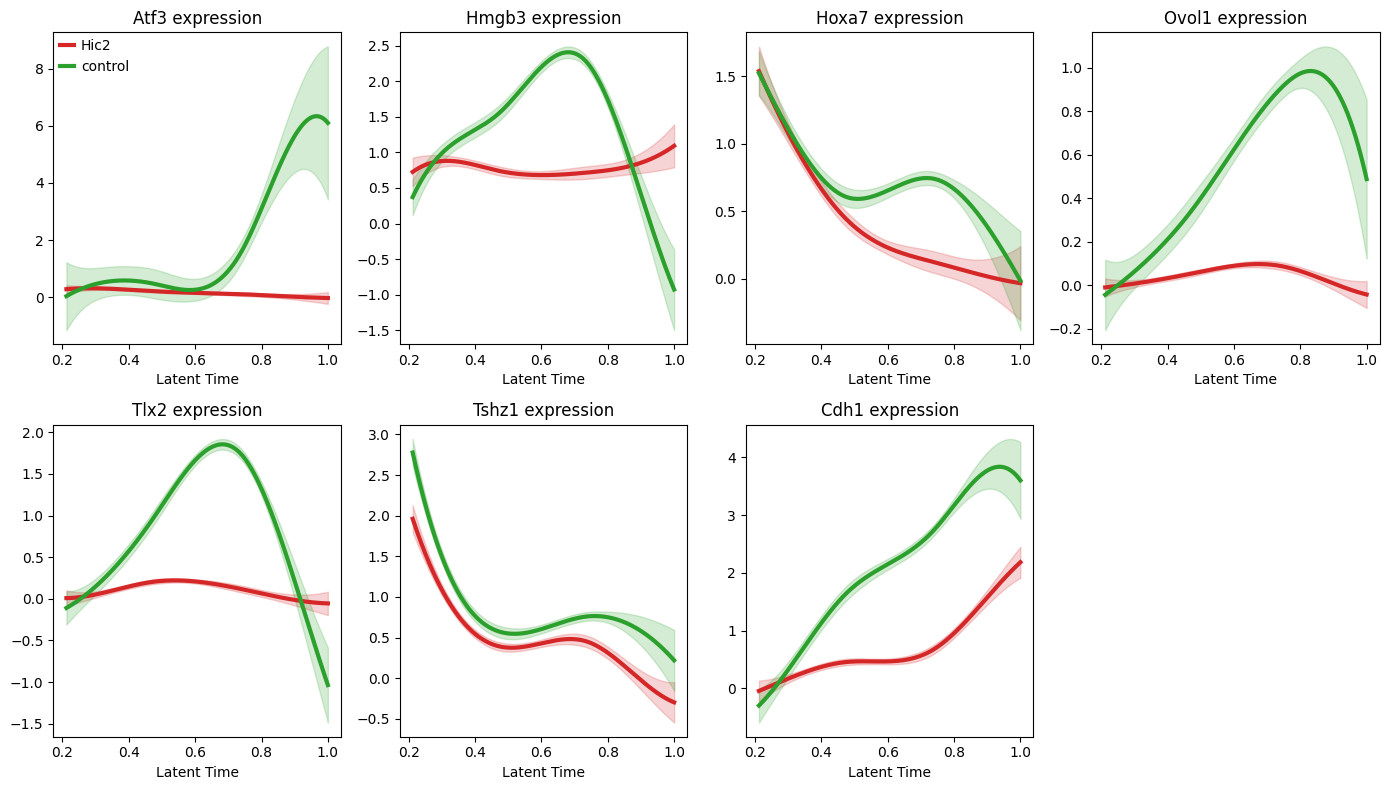

In [711]:
# Expression of dead end drivers

plot_grouped_gene_trend(
    adata, 
    list(dead_end_tfs)+["Cdh1"], 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

Ovol1, Cdh1, Tlx2 and Hmgb3 have the largest differences in expression between the groups. Once again, Ovol1 looks most promising. Atf3 does not look like a driver since it changes late in the process.

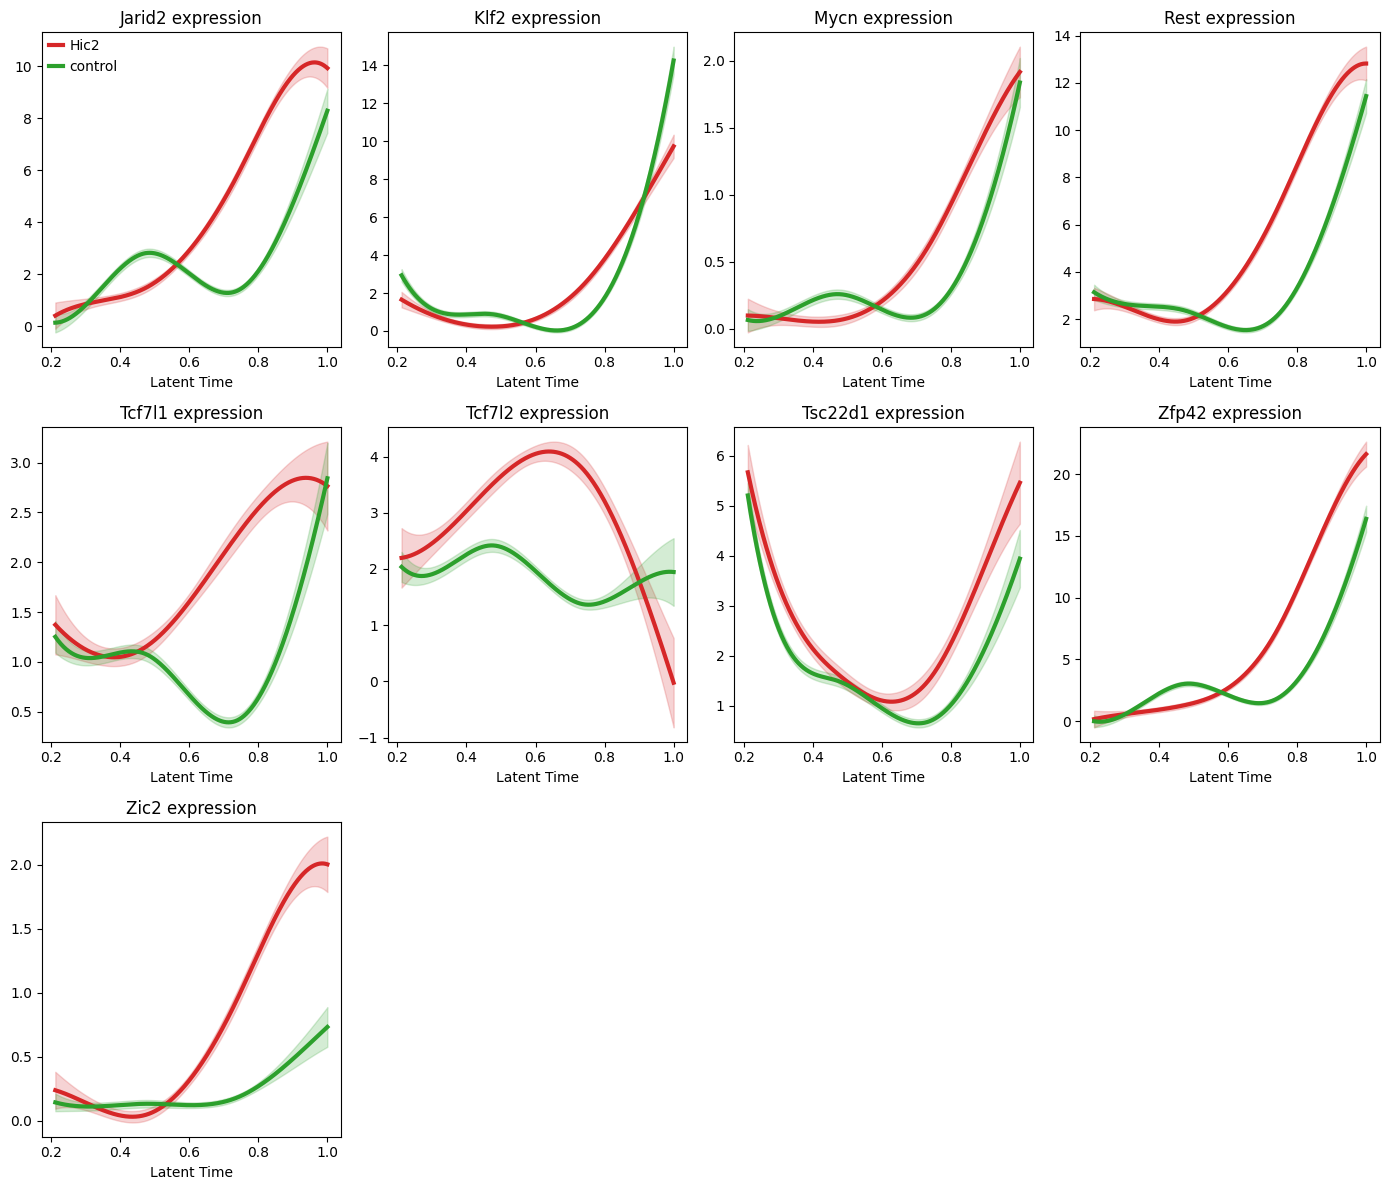

In [712]:
# Expression of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    stem_cell_tfs,
    group_key="group",
    layer="spliced",
    groups=["Hic2", "control"]
)

Jarid2, Tcf7l1, Rest and Tcf7l2 have the most interesting trends.

To do: Look at changes in transcription factor activity instead of mRNA levels. Below is a start for this

In [713]:
import gseapy as gp
import pandas as pd
import decoupler as dc

def load_enrichr_as_network(library_name):
    # 1. Download the library using GSEApy
    # Returns a dictionary: {'Term_Name': ['GeneA', 'GeneB', ...]}
    gs_dict = gp.get_library(name=library_name, organism='Mouse')
    
    network_list = []
    
    for term, genes in gs_dict.items():
        # The term usually looks like "KLF4 DOWN ..." or "KLF4_MOUSE_..."
        # We need to extract the TF name. 
        # CAUTION: This splitting depends on the specific naming convention of the library
        # For 'TF_Perturbations_Followed_by_Expression', format is often "TF_Perturbation_Direction"
        # We will attempt to grab the first word as the TF name
        if library_name in {"PerturbSeq_ReplogleK562", "PerturbSeq_ReplogleRPE1"}:
            tf_name = term.split()[1].upper()
        else:
            tf_name = term.split()[0].split('_')[0].upper() 
        
        for gene in genes:
            network_list.append({
                'source': tf_name,
                'target': gene,
                'weight': 1.0,      # We assume all targets are equal
                'collection': term  # Keep original term just in case
            })
            
    return pd.DataFrame(network_list)

In [714]:
# Use consensus network instead that also uses ChipSeq and motif data. Has Jarid in addition to the ones in TF_Perturbations_Followed_by_Expression,
# but gives values that do not work with Cellrank's gene_trends function
import decoupler as dc
net = dc.op.collectri(organism='mouse')

In [715]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-04 20:32:25 | [INFO] ulm - Running ulm
2026-02-04 20:32:25 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)


2026-02-04 20:32:25 | [INFO] Network adjacency matrix has 1111 unique features and 459 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-04 20:32:25 | [INFO] ulm - fitting 459 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-04 20:32:27 | [INFO] ulm - adjusting p-values by FDR
2026-02-04 20:32:27 | [INFO] ulm - done


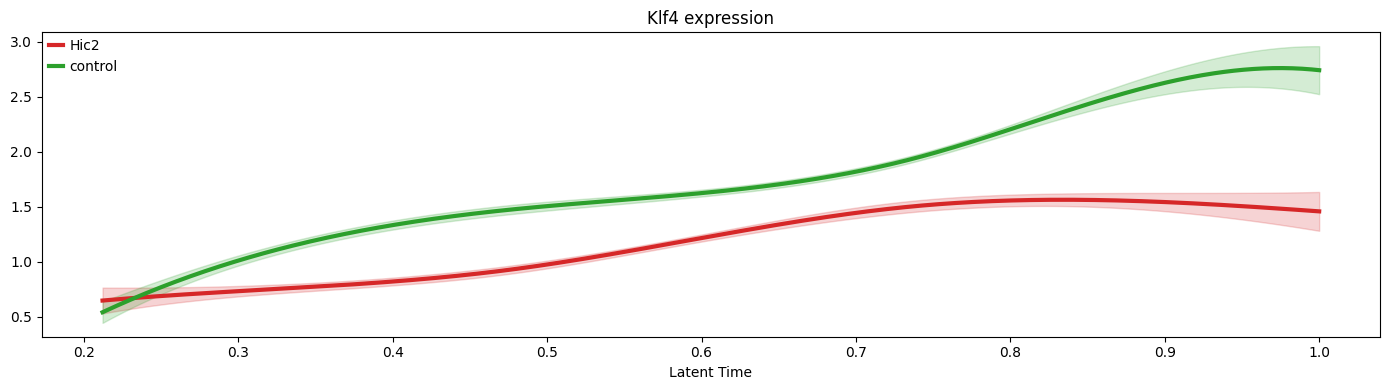

In [716]:
# Activity of Klf4

plot_grouped_gene_trend(
    adata,
    ["Klf4"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

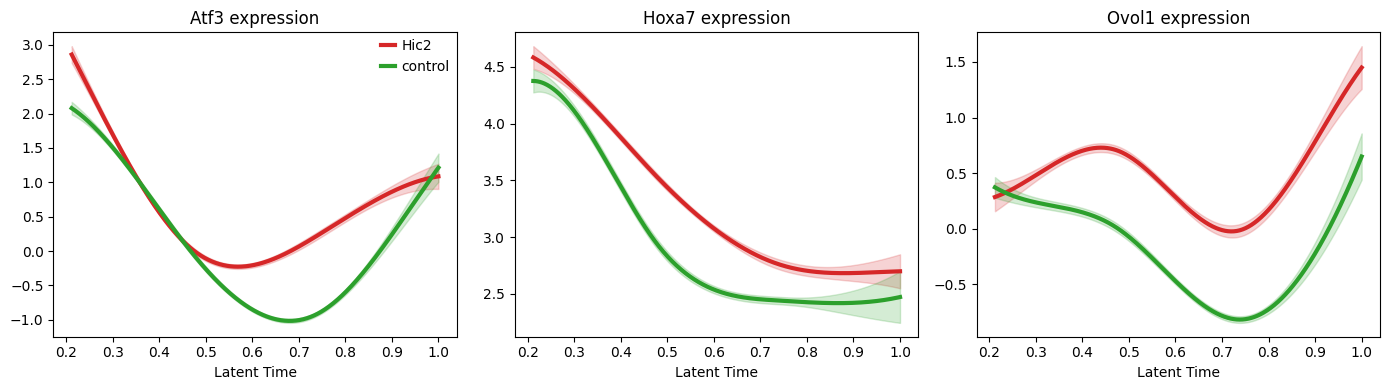

In [717]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Ovol1 expression is surprisingly higher in Hic2 cells.

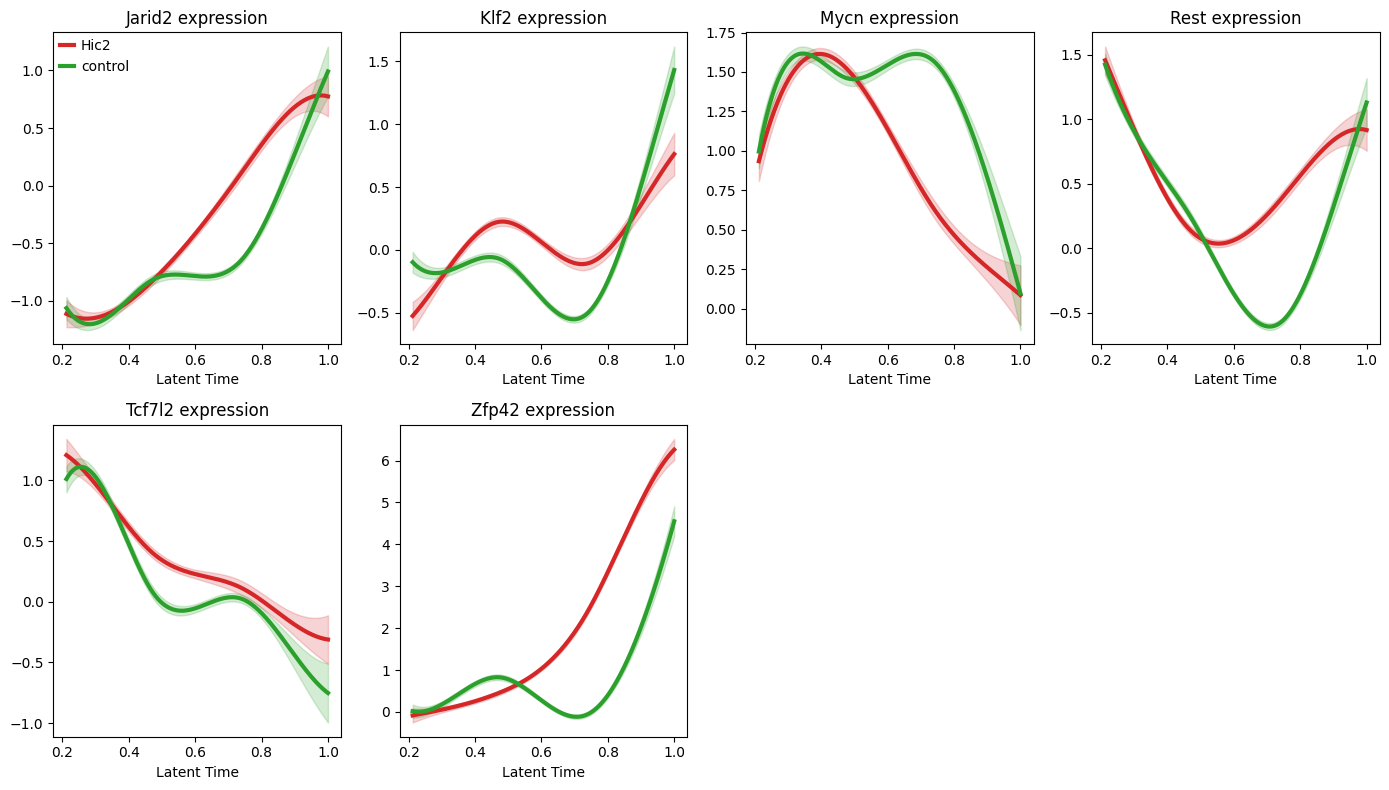

In [719]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Jarid2 and Zfp42 activities follow almost the exact same trends as their mRNA levels. They are similar until Hic2 and control cells start to take different trajectories. Rest has similar trends as its mRNA expression.

In [729]:
# Load another library
net = load_enrichr_as_network('TF_Perturbations_Followed_by_Expression') # Has the most genes because it is a collection

2026-02-04 20:34:36 | [INFO] Downloading and generating Enrichr library gene sets...
2026-02-04 20:34:36 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.TF_Perturbations_Followed_by_Expression.gmt, use local file


In [730]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-04 20:34:37 | [INFO] ulm - Running ulm
2026-02-04 20:34:37 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-02-04 20:34:37 | [INFO] Network adjacency matrix has 1749 unique features and 342 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-04 20:34:38 | [INFO] ulm - fitting 342 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-04 20:34:39 | [INFO] ulm - adjusting p-values by FDR
2026-02-04 20:34:39 | [INFO] ulm - done


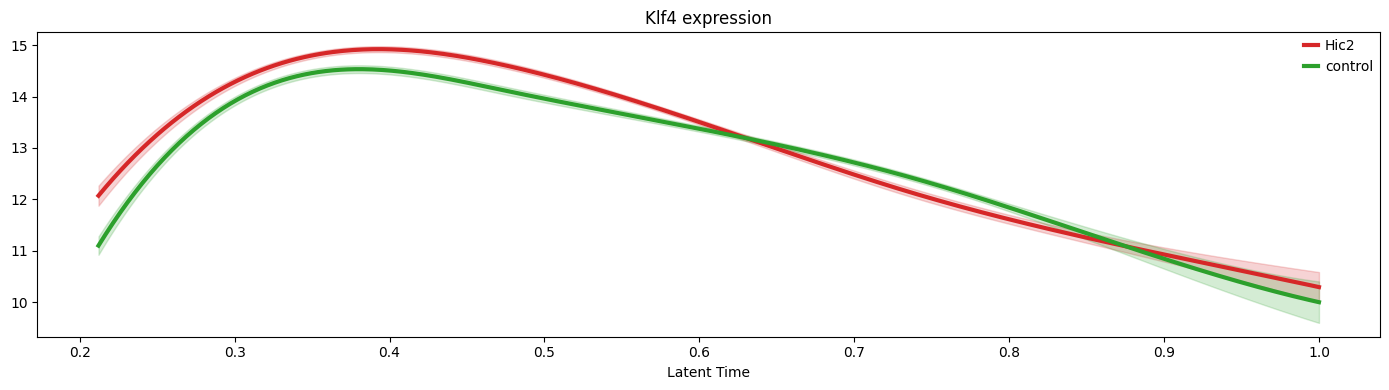

In [731]:
# Activity of Klf4

plot_grouped_gene_trend(
    adata,
    ["Klf4"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

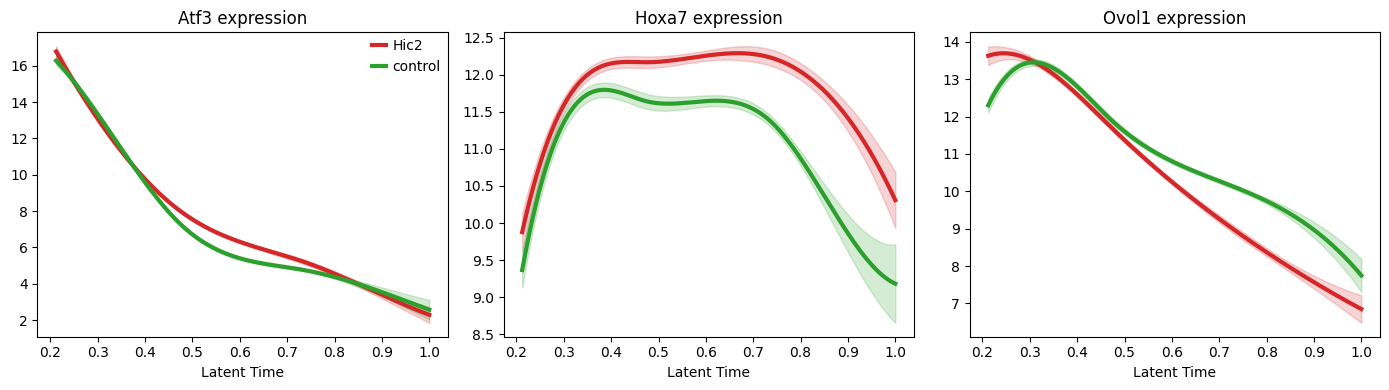

In [722]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

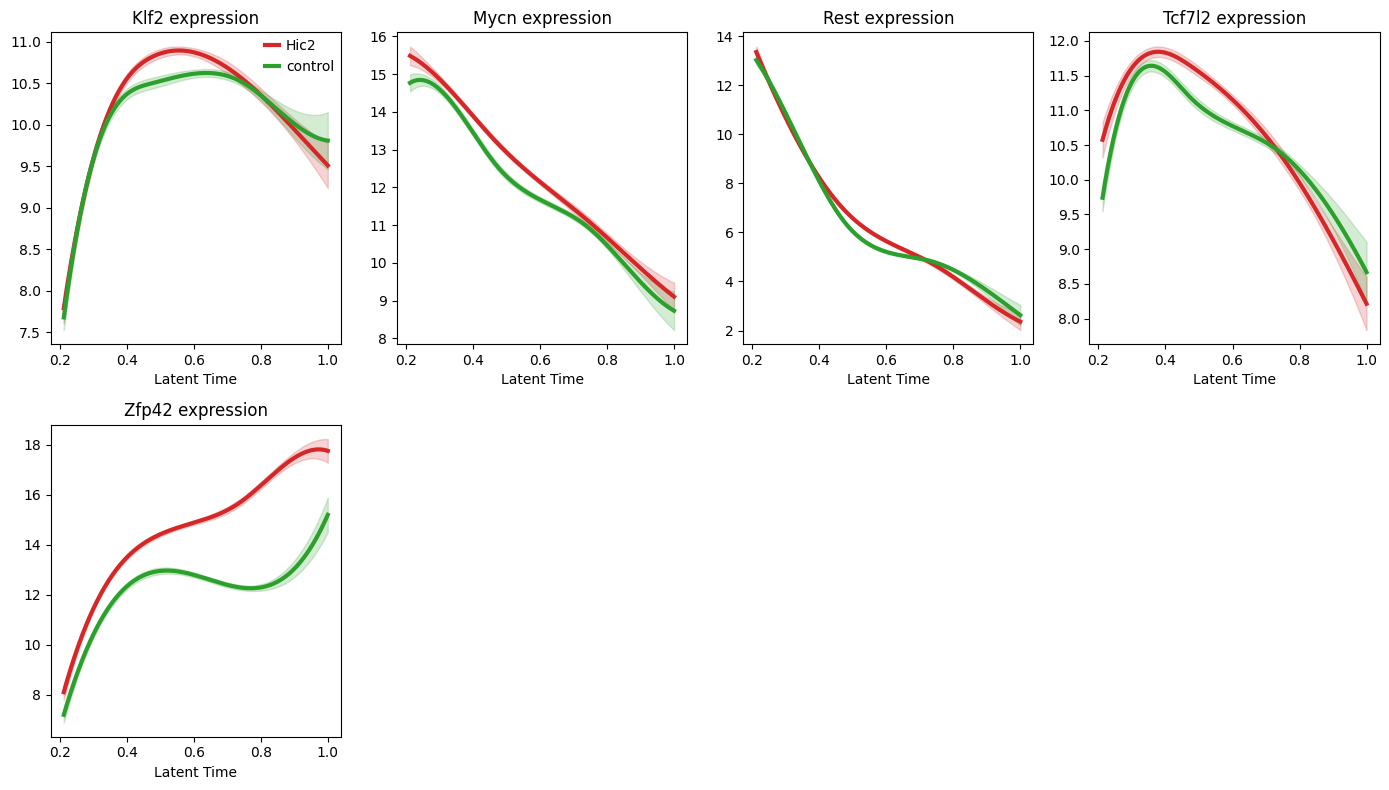

In [723]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

  0%|          | 0/3 [00:00<?, ?gene/s]

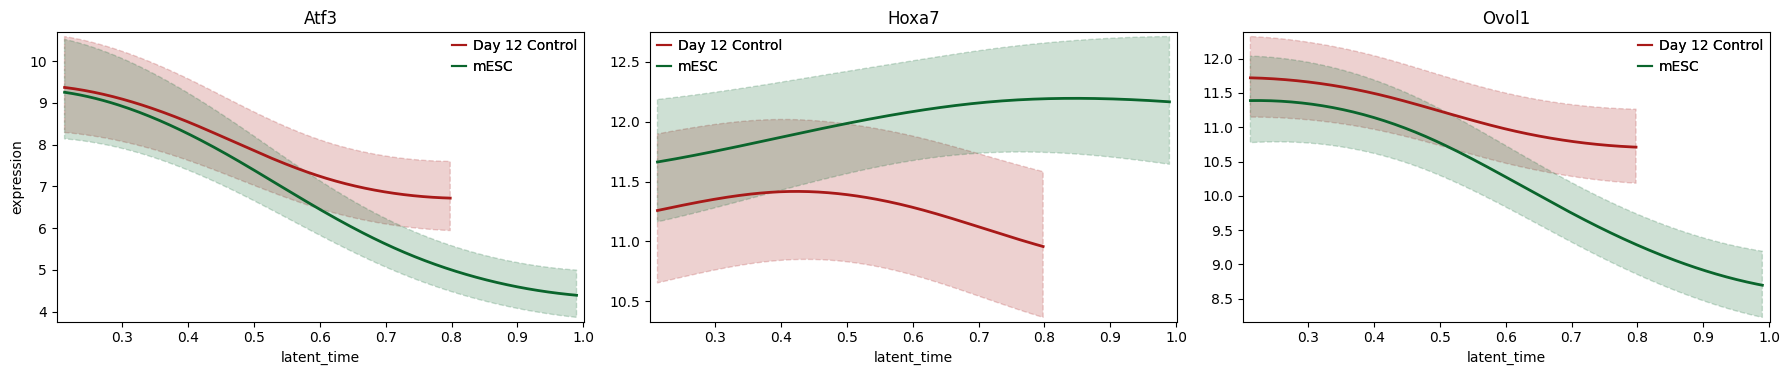

In [724]:
# Cellrank gene trends for dead end

import scanpy as sc
import cellrank as cr

def plot_tf_trends(adata, tfs, time_key, lineage_key='to_terminal_states', model=None):
    """
    Plots Decoupler TF activity scores using CellRank's gene_trends.
    """
    # 1. Extract the ULM scores (Cell x TF matrix)
    # Ensure you are using the correct key from your previous run (usually 'ulm_estimate')
    activity_matrix = adata.obsm['score_ulm'].copy()
    
    # 2. Create a new temporary AnnData object
    # The 'variables' (var) of this object are the TFs, not genes
    tf_adata = sc.AnnData(activity_matrix)
    tf_adata.obs = adata.obs.copy()  # Copy metadata (pseudotime, clusters)
    tf_adata.obsm = adata.obsm.copy() # Copy embeddings (UMAP) and lineage probs
    tf_adata.uns = adata.uns.copy()   # Copy CellRank lineage colors/names
    
    # 3. Setup the CellRank model if not provided
    if model is None:
        model = cr.models.GAM(tf_adata)
        
    # 4. Plot using the standard function
    # Note: data_key='X' because we put the scores in .X of the new object
    cellrank.pl.gene_trends(
    tf_adata,
    model=model,
    genes=tfs,
    data_key="X",
    same_plot=True,
    ncols=4,
    time_key=time_key,
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)

# --- Usage ---
# Assuming you have already run CellRank and calculated pseudotime
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time' # or 'dpt_pseudotime'
)

Ovol1 once again seems like a dead end driver.

  0%|          | 0/5 [00:00<?, ?gene/s]

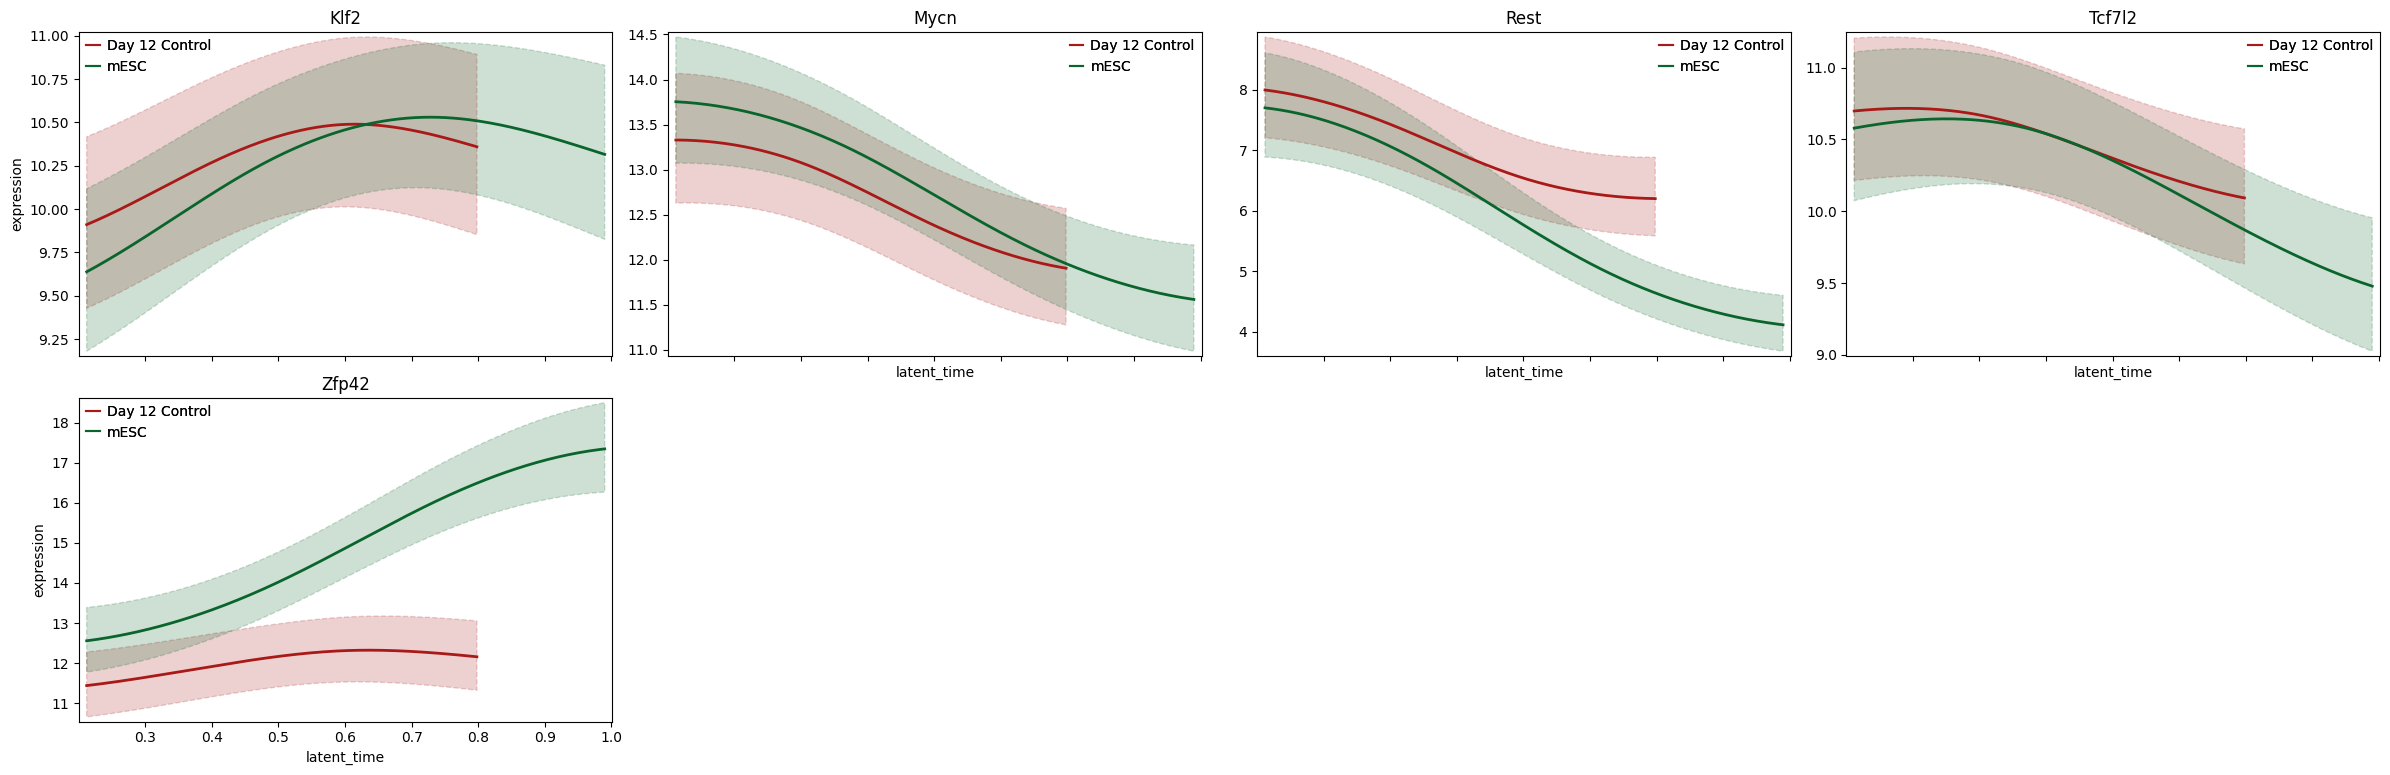

In [725]:
# Cellrank gene trends for stem cells

import scanpy as sc
import cellrank as cr

def plot_tf_trends(adata, tfs, time_key, lineage_key='to_terminal_states', model=None):
    """
    Plots Decoupler TF activity scores using CellRank's gene_trends.
    """
    # 1. Extract the ULM scores (Cell x TF matrix)
    # Ensure you are using the correct key from your previous run (usually 'ulm_estimate')
    activity_matrix = adata.obsm['score_ulm'].copy()
    
    # 2. Create a new temporary AnnData object
    # The 'variables' (var) of this object are the TFs, not genes
    tf_adata = sc.AnnData(activity_matrix)
    tf_adata.obs = adata.obs.copy()  # Copy metadata (pseudotime, clusters)
    tf_adata.obsm = adata.obsm.copy() # Copy embeddings (UMAP) and lineage probs
    tf_adata.uns = adata.uns.copy()   # Copy CellRank lineage colors/names
    
    # 3. Setup the CellRank model if not provided
    if model is None:
        model = cr.models.GAM(tf_adata)
        
    # 4. Plot using the standard function
    # Note: data_key='X' because we put the scores in .X of the new object
    cellrank.pl.gene_trends(
    tf_adata,
    model=model,
    genes=tfs,
    data_key="X",
    same_plot=True,
    ncols=4,
    time_key=time_key,
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)

# --- Usage ---
# Assuming you have already run CellRank and calculated pseudotime
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time' # or 'dpt_pseudotime'
)

Zfp42 activity is very interesting, as it differs even early in latent time. The other genes do not look like clear reprogramming drivers.

In [726]:
# A library from CRISPR screen
net = load_enrichr_as_network('PerturbSeq_ReplogleK562')

# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-04 20:33:33 | [INFO] Downloading and generating Enrichr library gene sets...
2026-02-04 20:33:39 | [INFO] ulm - Running ulm
2026-02-04 20:33:39 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-02-04 20:33:39 | [INFO] Network adjacency matrix has 499 unique features and 1477 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-04 20:33:39 | [INFO] ulm - fitting 1477 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-04 20:33:44 | [INFO] ulm - adjusting p-values by FDR
2026-02-04 20:33:44 | [INFO] ulm - done


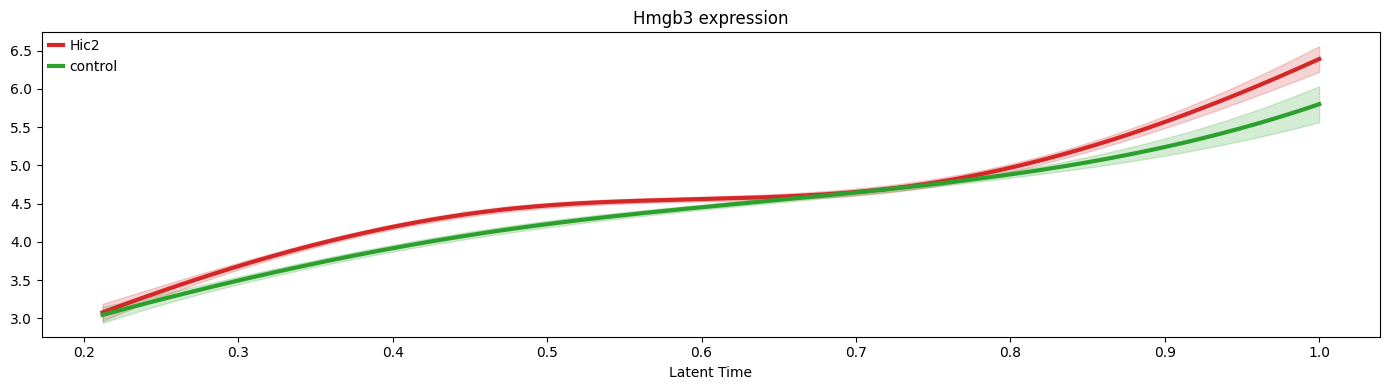

In [727]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

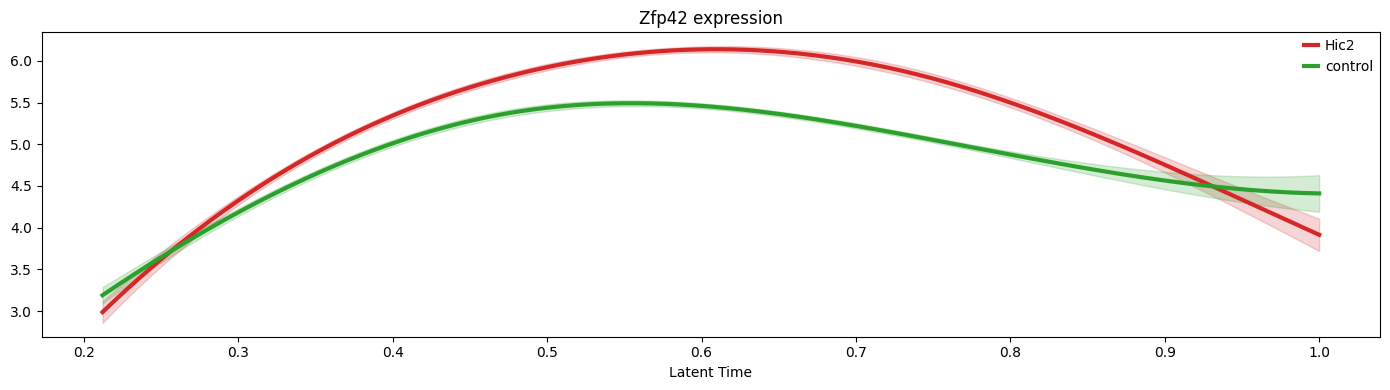

In [728]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)